In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px

In [2]:
# pastikan nama file sesuai dengan yang ada di Google Colab, misal:
file_path = "/content/Dataset Canada.xlsx"

# membaca sheet "Canada by Citizenship" dengan header pada baris ke-21
df = pd.read_excel(file_path, sheet_name='Canada by Citizenship', header=20)
df.head()

,Type,Coverage,OdName,AREA,AreaName,REG,RegName,DEV,DevName,1980,...,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013
0,Immigrants,Foreigners,Afghanistan,935,Asia,5501,Southern Asia,902,Developing regions,16,...,2978,3436,3009,2652,2111,1746,1758,2203,2635,2004
1,Immigrants,Foreigners,Albania,908,Europe,925,Southern Europe,901,Developed regions,1,...,1450,1223,856,702,560,716,561,539,620,603
2,Immigrants,Foreigners,Algeria,903,Africa,912,Northern Africa,902,Developing regions,80,...,3616,3626,4807,3623,4005,5393,4752,4325,3774,4331
3,Immigrants,Foreigners,American Samoa,909,Oceania,957,Polynesia,902,Developing regions,0,...,0,0,1,0,0,0,0,0,0,0
4,Immigrants,Foreigners,Andorra,908,Europe,925,Southern Europe,901,Developed regions,0,...,0,0,1,1,0,0,0,0,1,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197 entries, 0 to 196
Data columns (total 43 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Type      197 non-null    object
 1   Coverage  197 non-null    object
 2   OdName    197 non-null    object
 3   AREA      197 non-null    int64 
 4   AreaName  197 non-null    object
 5   REG       197 non-null    int64 
 6   RegName   197 non-null    object
 7   DEV       197 non-null    int64 
 8   DevName   197 non-null    object
 9   1980      197 non-null    int64 
 10  1981      197 non-null    int64 
 11  1982      197 non-null    int64 
 12  1983      197 non-null    int64 
 13  1984      197 non-null    int64 
 14  1985      197 non-null    int64 
 15  1986      197 non-null    int64 
 16  1987      197 non-null    int64 
 17  1988      197 non-null    int64 
 18  1989      197 non-null    int64 
 19  1990      197 non-null    int64 
 20  1991      197 non-null    int64 
 21  1992      197 no

In [4]:
stats = df.describe()
stats

,AREA,REG,DEV,1980,1981,1982,1983,1984,1985,1986,...,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013
count,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,...,197.000000,197.00000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000
mean,913.639594,1246.477157,902.741117,1453.167513,1306.000000,1230.203046,905.431472,896.162437,856.304569,1008.639594,...,2394.131980,2662.35533,2554.720812,2403.583756,2510.091371,2560.101523,2849.614213,2525.360406,2618.304569,2629.654822
std,15.637379,1179.730385,9.782793,10784.524807,9449.373841,8864.905615,6503.149859,6452.570413,6155.858422,7205.630681,...,17119.626937,19104.65330,18261.461660,17129.490442,17908.071420,18276.881231,20386.174875,18082.496369,18763.159434,18838.224387
min,903.000000,905.000000,901.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,903.000000,914.000000,902.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,21.000000,29.00000,26.000000,32.000000,32.000000,37.000000,42.000000,38.000000,43.000000,45.000000
50%,908.000000,922.000000,902.000000,14.000000,10.000000,12.000000,12.000000,14.000000,17.000000,21.000000,...,196.000000,211.00000,230.000000,198.000000,205.000000,217.000000,216.000000,196.000000,235.000000,217.000000
75%,935.000000,926.000000,902.000000,266.000000,299.000000,299.000000,197.000000,207.000000,202.000000,257.000000,...,866.000000,857.00000,856.000000,975.000000,975.000000,917.000000,953.000000,851.000000,799.000000,852.000000
max,999.000000,5501.000000,999.000000,143137.000000,128641.000000,121175.000000,89185.000000,88272.000000,84346.000000,99351.000000,...,235822.000000,262242.00000,251640.000000,236753.000000,247244.000000,252170.000000,280687.000000,248748.000000,257903.000000,259021.000000


In [5]:
df.columns = df.columns.map(str)
years = [str(y) for y in range(2000, 2014)]
df_time = df[['OdName'] + years].copy()

# ubah nilai jadi numerik dan isi NaN dengan 0
for y in years:
    df_time[y] = pd.to_numeric(df_time[y], errors='coerce').fillna(0).astype(int)

df_time.head()

,OdName,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013
0,Afghanistan,3326,4067,3697,3479,2978,3436,3009,2652,2111,1746,1758,2203,2635,2004
1,Albania,1816,1602,1021,853,1450,1223,856,702,560,716,561,539,620,603
2,Algeria,2867,3418,3406,3072,3616,3626,4807,3623,4005,5393,4752,4325,3774,4331
3,American Samoa,0,0,0,0,0,0,1,0,0,0,0,0,0,0
4,Andorra,0,1,0,2,0,0,1,1,0,0,0,0,1,1


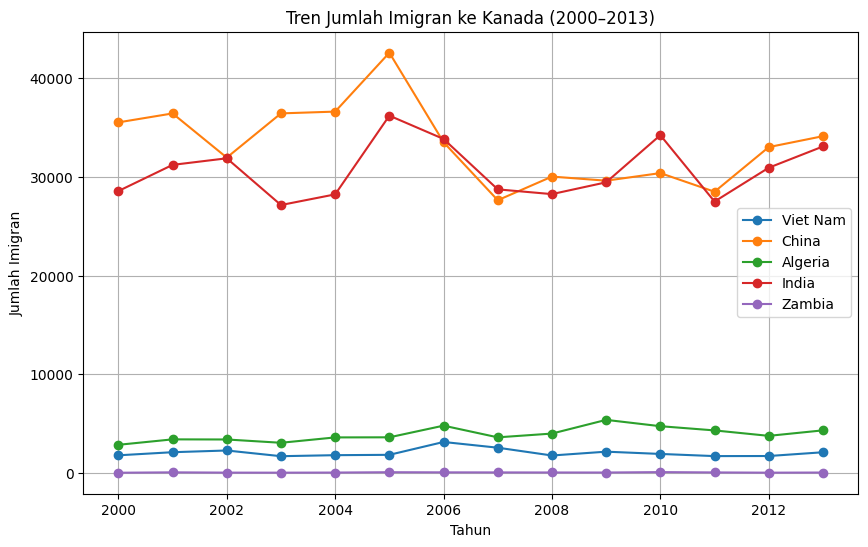

In [6]:
targets = ['Viet Nam','China','Algeria','India','Zambia']
plt.figure(figsize=(10,6))

for country in targets:
    row = df_time[df_time['OdName'].str.contains(country, case=False)]
    if not row.empty:
        plt.plot([int(y) for y in years], row.iloc[0,1:].values, marker='o', label=country)

plt.title('Tren Jumlah Imigran ke Kanada (2000–2013)')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Imigran')
plt.legend()
plt.grid(True)
plt.show()

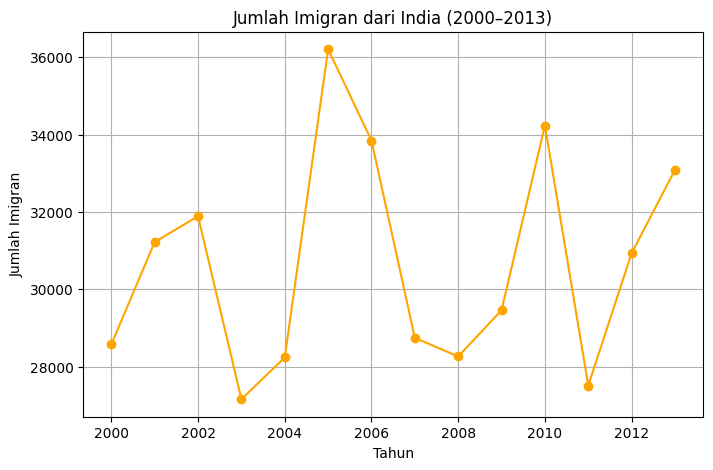

In [7]:
india = df_time[df_time['OdName'].str.contains('India', case=False)].iloc[0]
plt.figure(figsize=(8,5))
plt.plot([int(y) for y in years], india[years].values, marker='o', color='orange')
plt.title('Jumlah Imigran dari India (2000–2013)')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Imigran')
plt.grid(True)
plt.show()

In [8]:
ys = india[years].values.astype(float)
xs = np.array([int(y) for y in years])
A = np.vstack([xs, np.ones_like(xs)]).T
m, c = np.linalg.lstsq(A, ys, rcond=None)[0]
trend = 'naik' if m > 0 else ('turun' if m < 0 else 'stabil')

print(f"Nilai kemiringan (slope): {m:.2f}")
print(f"Tren jumlah imigran dari India tahun 2000–2013: {trend}")

Nilai kemiringan (slope): 94.06
Tren jumlah imigran dari India tahun 2000–2013: naik


In [9]:
df_time['Total'] = df_time[years].sum(axis=1)
top10 = df_time.nlargest(10, 'Total')

fig = px.choropleth(
    top10,
    locations='OdName',
    locationmode='country names',
    color='Total',
    hover_name='OdName',
    title='Asal Negara Imigran ke Kanada (2000–2013)',
    color_continuous_scale='Blues'
)
fig.show()